# Reformat CSV file
- Load Raw data file
- Clean dataset from
    - Finished == False
    - Attention check != 'neither agree nor disagree'
- Structure Cleaned dataset
-   Add variable and measurements names for each question

In [20]:
import pandas as pd

# Load the CSV dataset
df = pd.read_csv('dataset/final_raw_dataset.csv')

# Drop unfinished responses and failed attention checks
finished_mask = df['Finished'].astype(str).str.lower() != 'false'
attention_mask = df['Q28'] == 'Neither agree nor disagree'
df = df[finished_mask & attention_mask].copy()

# Display first few rows
df

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q22,Q23,Q21,Q26,Q27,Q_RecaptchaStatus,Q_RecaptchaError,Q_TerminateFlag,Condition,FL_7_DO
2,2026-05-07 13:49:00,2026-05-07 13:53:07,IP Address,172.225.253.133,100,247,True,2026-05-07 21:25:10,R_8P6GTJsPaZHn06d,NaN,...,Somewhat agree,Somewhat disagree,Somewhat disagree,18 - 24,Female,complete,NaN,NaN,Low,FL_31
3,2026-05-07 14:35:49,2026-05-07 14:39:10,IP Address,95.96.47.160,100,201,True,2026-05-07 21:26:54,R_8iI6DtbsaO53vzz,NaN,...,Neither agree nor disagree,Disagree,Disagree,25 - 34,Male,complete,NaN,NaN,High,FL_29
4,2026-05-07 15:13:59,2026-05-07 15:20:45,IP Address,172.225.253.128,100,406,True,2026-05-07 21:33:16,R_2cZckTBVx5YXI3v,NaN,...,Somewhat disagree,Somewhat disagree,Disagree,18 - 24,Female,complete,NaN,NaN,High,FL_29
5,2026-05-07 18:03:44,2026-05-07 18:06:28,IP Address,217.105.50.232,100,164,True,2026-05-07 21:38:02,R_2sTk4rSjkovtway,NaN,...,Disagree,Disagree,Disagree,18 - 24,Female,complete,NaN,NaN,Low,FL_31
6,2026-05-07 18:39:52,2026-05-07 18:43:20,IP Address,109.38.152.171,100,208,True,2026-05-07 21:39:06,R_8IBf432pfgNRYUR,NaN,...,Disagree,Disagree,Disagree,18 - 24,Female,complete,NaN,NaN,High,FL_29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,2026-05-31 08:52:43,2026-05-31 08:54:39,IP Address,194.107.161.118,100,116,True,2026-05-29 15:54:52,R_9rC3mV5b7bXFWj6,NaN,...,Somewhat disagree,Somewhat disagree,Neither agree nor disagree,25 - 34,Female,complete,NaN,NaN,Low,FL_31
338,2026-05-31 08:54:51,2026-05-31 08:57:10,IP Address,194.107.161.119,100,139,True,2026-05-29 15:57:15,R_9wkJRqrt8iCxQ4N,NaN,...,Somewhat disagree,Somewhat disagree,Somewhat disagree,18 - 24,Female,complete,NaN,NaN,High,FL_29
339,2026-05-31 09:23:27,2026-05-31 09:26:08,IP Address,194.107.161.120,100,161,True,2026-05-29 15:59:58,R_4NESzufZ3ZbzRBg,NaN,...,Somewhat agree,Neither agree nor disagree,Neither agree nor disagree,25 - 34,Male,complete,NaN,NaN,Low,FL_31
340,2026-05-31 18:40:10,2026-05-31 18:43:20,IP Address,194.107.161.121,100,190,True,2026-05-29 16:03:11,R_9v98q5Y9SVmUbJC,NaN,...,Somewhat disagree,Somewhat disagree,Somewhat disagree,35 - 44,Female,complete,NaN,NaN,High,FL_29


In [21]:
# trim df to keep only question columns and the Condition column
question_condition_cols = [
    col for col in df.columns
    if (col.startswith('Q') and col[1].isdigit()) or col == 'Condition'
]
df = df.loc[:, question_condition_cols].copy()

# Drop the first row (JSON import IDs) and reset index, keeping the question row as index 0
df = df.iloc[1:].reset_index(drop=True)

In [22]:
# Add variable names and main measurement variables as new rows beneath the question row

mapping = pd.read_csv('dataset/dataset_table_names.csv').set_index('Q#')

# Create dataframe for new rows
new_df = pd.DataFrame(index=[0, 1], columns=df.columns)
for col in df.columns:
    if col in mapping.index:
        new_df.at[0, col] = mapping.at[col, 'New Name Variable']
        new_df.at[1, col] = mapping.at[col, 'Main Measurement Variable']
    else:
        new_df.at[0, col] = ''
        new_df.at[1, col] = ''

# Insert the new rows after the first row (question row)
df = pd.concat([df.iloc[:1], new_df, df.iloc[1:]], ignore_index=True)
# drop Q1
df = df.drop('Q1', axis=1)
# drop row 0
df = df.drop(0, axis=0).reset_index(drop=True)

# Save cleaned dataset
df.to_csv('dataset/final_clean_dataset.csv', index=False)

df

,Q24,Q29,Q33,Q12,Q13,Q14,Q9,Q10,Q11,Q15,...,Q28,Q18,Q19,Q20,Q22,Q23,Q21,Q26,Q27,Condition
0,Transparency_explanation,Transparency_data,Transparency_limitation,Persuasion_sell,Persuasion_influence,Persuasion_brand,Privacy_tracking,Privacy_excessive_info,Privacy_unforeseen_use,Loyalty_repeat_purchase,...,Attention_check,AILiteracy_distinguish_ads,AILiteracy_data_usage,AILiteracy_evaluate_limits,Control_manage_input,Control_collection,Control_processing,Demographic_age,Demographic_gender,
1,Transparency,Transparency,Transparency,Persuasion Knowledge Activation,Persuasion Knowledge Activation,Persuasion Knowledge Activation,Privacy Concern,Privacy Concern,Privacy Concern,Customer Loyalty,...,Attention check,AI Literacy,AI Literacy,AI Literacy,Perceived Data Control,Perceived Data Control,Perceived Data Control,Demographic,Demographic,
2,Strongly agree,Strongly agree,Neither agree nor disagree,Agree,Somewhat agree,Disagree,Agree,Agree,Somewhat agree,Agree,...,Neither agree nor disagree,Somewhat agree,Strongly agree,Strongly agree,Somewhat disagree,Somewhat disagree,Disagree,18 - 24,Female,High
3,Disagree,Disagree,Disagree,Strongly agree,Agree,Agree,Agree,Agree,Agree,Somewhat agree,...,Neither agree nor disagree,Strongly disagree,Strongly disagree,Strongly disagree,Disagree,Disagree,Disagree,18 - 24,Female,Low
4,Agree,Agree,Disagree,Agree,Agree,Agree,Agree,Agree,Agree,Disagree,...,Neither agree nor disagree,Agree,Somewhat agree,Somewhat agree,Disagree,Disagree,Disagree,18 - 24,Female,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Somewhat agree,Somewhat agree,Disagree,Somewhat agree,Neither agree nor disagree,Neither agree nor disagree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,...,Neither agree nor disagree,Agree,Agree,Disagree,Somewhat disagree,Somewhat disagree,Neither agree nor disagree,25 - 34,Female,Low
239,Strongly agree,Strongly agree,Agree,Somewhat agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Somewhat disagree,...,Neither agree nor disagree,Somewhat disagree,Somewhat disagree,Disagree,Somewhat disagree,Somewhat disagree,Somewhat disagree,18 - 24,Female,High
240,Somewhat agree,Somewhat disagree,Disagree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat disagree,Somewhat agree,Neither agree nor disagree,Neither agree nor disagree,25 - 34,Male,Low
241,Strongly agree,Strongly agree,Strongly agree,Agree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Neither agree nor disagree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat disagree,Somewhat disagree,Somewhat disagree,35 - 44,Female,High


# Reliability Analysis
- Cronbach's Alpha


### Split df based on condition

In [23]:
df_high = df[df['Condition'] == 'High']
df_low = df[df['Condition'] == 'Low']

print(len(df_high))
print(len(df_low))

128
113


### Compute reliability scores

In [24]:
import numpy as np

# Mapping for Likert scale responses
likert_map = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Somewhat disagree': 3,
    'Neither agree nor disagree': 4,
    'Somewhat agree': 5,
    'Agree': 6,
    'Strongly agree': 7
}

# Function to compute Cronbach's alpha
def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    if k < 2:
        return np.nan
    variances = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_var)
    return alpha

# Extract metadata rows and response rows
var_names = df.loc[0]
measurements = df.loc[1]
responses = df.loc[2:].reset_index(drop=True)

# Identify scales from measurement variables (row 1)
scales = {}
for col in df.columns:
    if col == 'Condition':
        continue
    meas = measurements[col]
    if pd.isna(meas) or meas == '':
        continue
    scales.setdefault(meas, []).append(col)

# Helper to compute reliability per group
def reliability_report(group_df, group_name):
    print(f"\nReliability for {group_name} condition")
    for scale, cols in scales.items():
        data = group_df.loc[:, cols].replace(likert_map)
        data = data.apply(pd.to_numeric, errors='coerce')
        alpha = cronbach_alpha(data)
        print(f"Cronbach's alpha for {scale}: {alpha:.3f}")

# Overall and by condition
reliability_report(responses, 'All')
reliability_report(df_high, 'High')
reliability_report(df_low, 'Low')


Reliability for All condition
Cronbach's alpha for Transparency: 0.844
Cronbach's alpha for Persuasion Knowledge Activation: 0.631
Cronbach's alpha for Privacy Concern: 0.939
Cronbach's alpha for Customer Loyalty: 0.789
Cronbach's alpha for Attention check: nan
Cronbach's alpha for AI Literacy: 0.785
Cronbach's alpha for Perceived Data Control: 0.718
Cronbach's alpha for Demographic: nan

Reliability for High condition
Cronbach's alpha for Transparency: 0.593
Cronbach's alpha for Persuasion Knowledge Activation: 0.530
Cronbach's alpha for Privacy Concern: 0.914
Cronbach's alpha for Customer Loyalty: 0.833
Cronbach's alpha for Attention check: nan
Cronbach's alpha for AI Literacy: 0.787
Cronbach's alpha for Perceived Data Control: 0.793
Cronbach's alpha for Demographic: nan

Reliability for Low condition
Cronbach's alpha for Transparency: 0.743
Cronbach's alpha for Persuasion Knowledge Activation: 0.745
Cronbach's alpha for Privacy Concern: 0.949
Cronbach's alpha for Customer Loyalty: 

In [25]:
# Compute mean and standard deviation for each construct
construct_stats = {}
for scale, cols in scales.items():
    data = responses.loc[:, cols].replace(likert_map)
    data = data.apply(pd.to_numeric, errors='coerce')
    scale_scores = data.mean(axis=1)
    construct_stats[scale] = {
        'mean': scale_scores.mean(),
        'std': scale_scores.std(),
        'n': scale_scores.count()
    }

stats_df = pd.DataFrame.from_dict(construct_stats, orient='index')
stats_df = stats_df[['n', 'mean', 'std']]
print('Construct mean and standard deviation:')
print(stats_df.round(3))


Construct mean and standard deviation:
                                   n   mean    std
Transparency                     241  4.094  1.813
Persuasion Knowledge Activation  241  5.329  0.975
Privacy Concern                  241  5.898  1.234
Customer Loyalty                 241  4.113  1.101
Attention check                  241  4.000  0.000
AI Literacy                      241  4.607  1.270
Perceived Data Control           241  3.277  1.054
Demographic                        0    NaN    NaN


# Data Analysis

### Visualization

This section shows several views of scale reliability for each measurement construct.

- **Item mean scores**: plots each item mean as a point with error bars. This shows whether items are centered similarly and how much they vary. If item means are far apart, the scale may lack uniformity, but this does not by itself prove poor reliability.

- **Item correlation heatmap**: displays pairwise correlations between items within the same scale. Cronbach's alpha depends on these item correlations. Strong positive correlations support a higher alpha.

- **Item-total correlations**: shows how well each item correlates with the sum of the remaining items. Low item-total correlation indicates an item is not consistent with the rest of the scale and can weaken alpha.

- **Alpha if item deleted**: computes Cronbach's alpha after dropping each item. If alpha increases substantially when an item is removed, that item is reducing scale reliability.

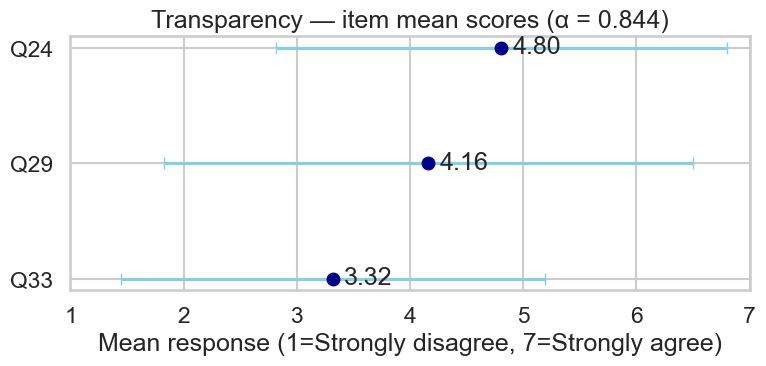

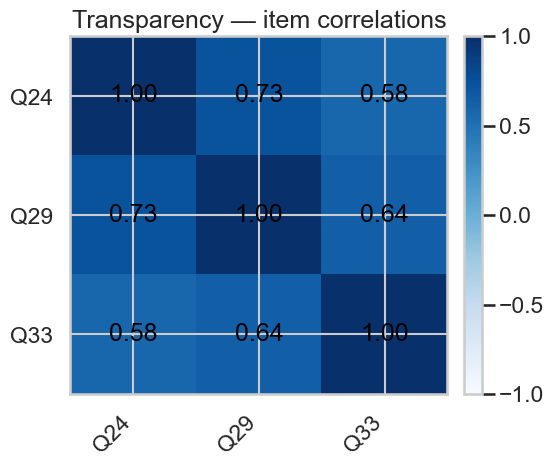

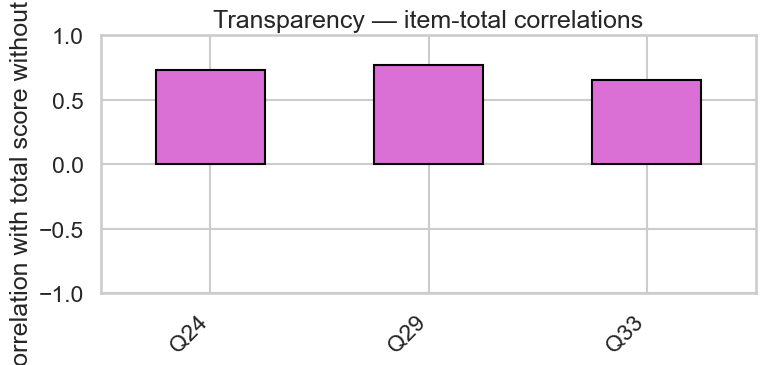

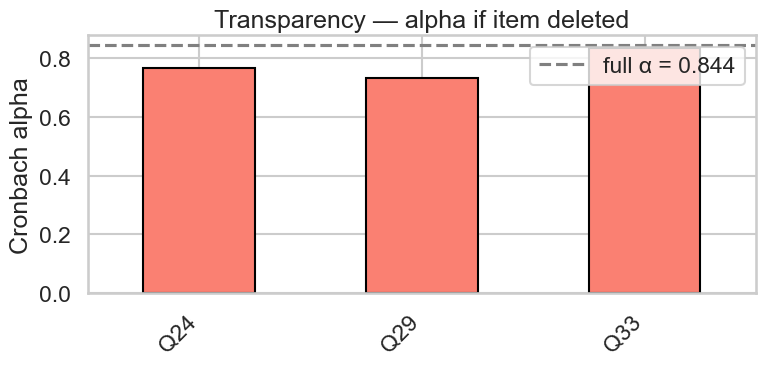

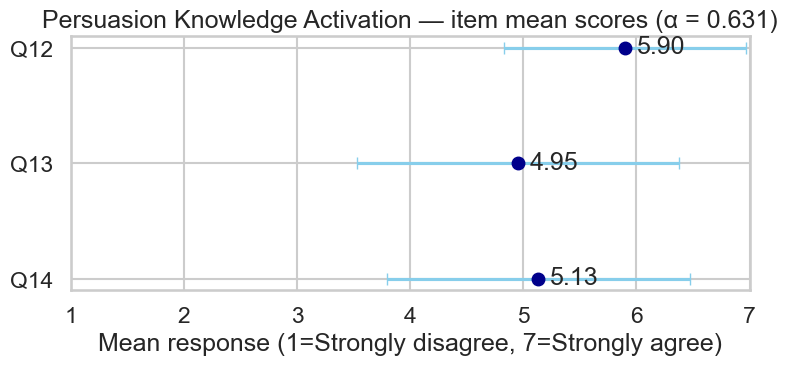

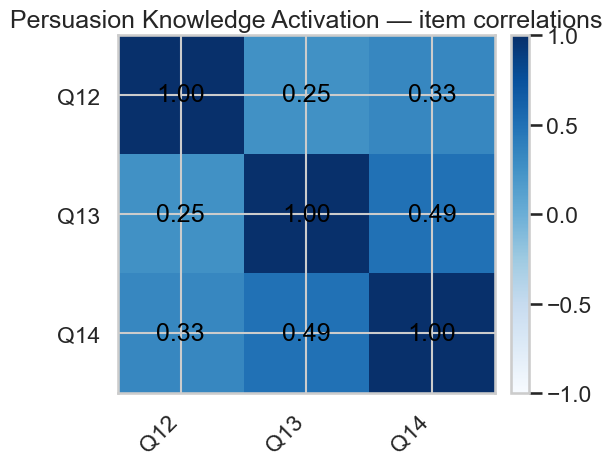

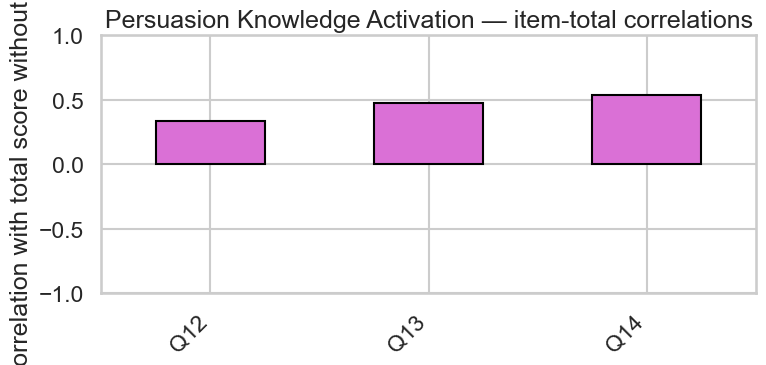

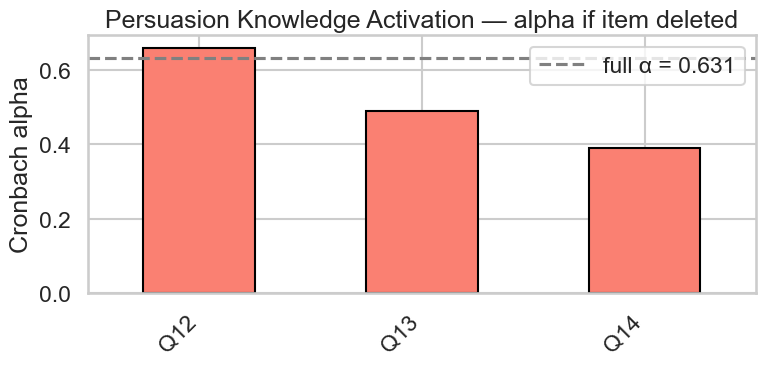

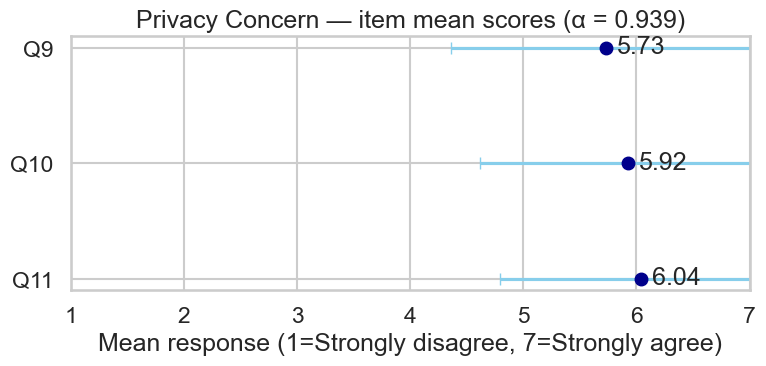

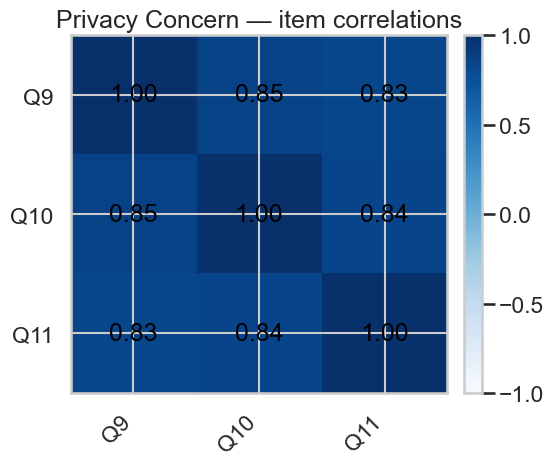

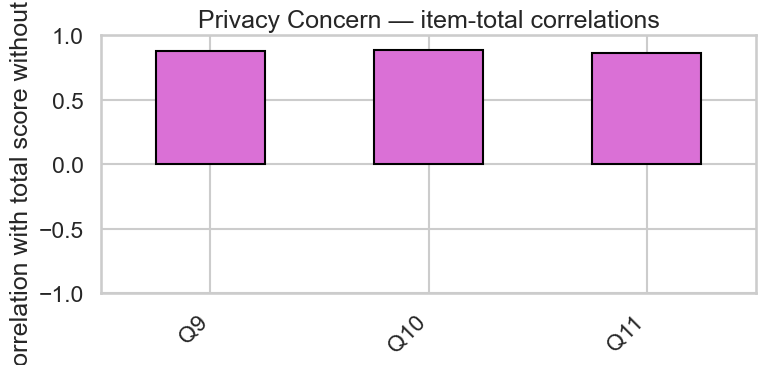

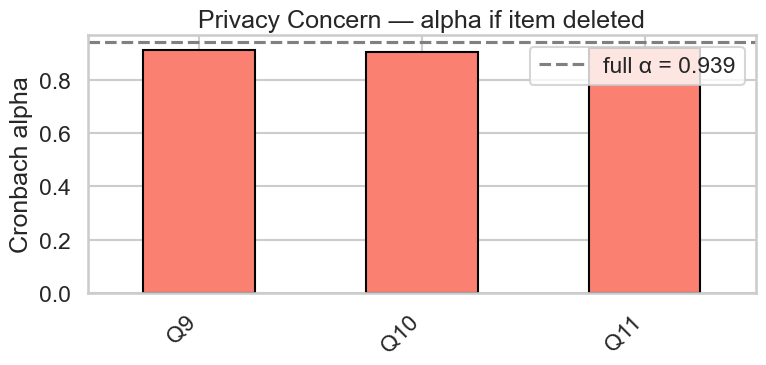

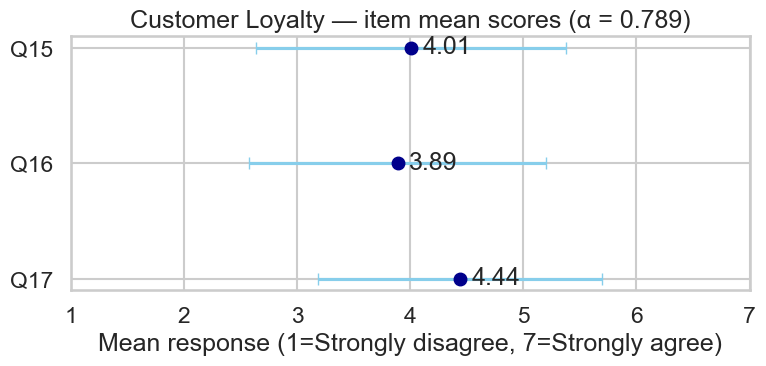

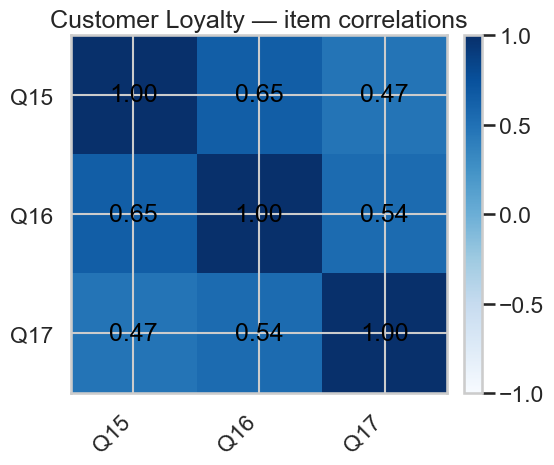

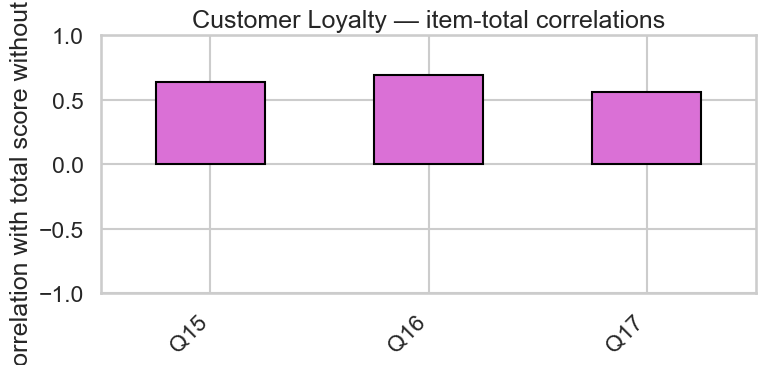

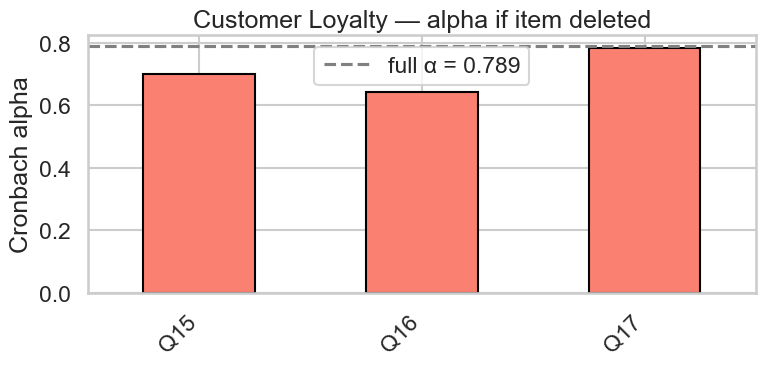

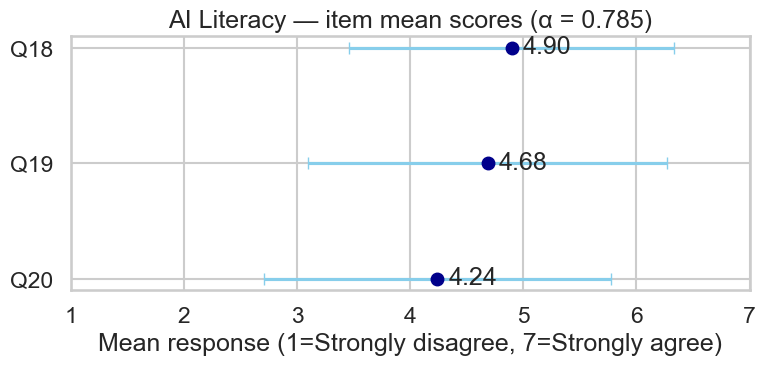

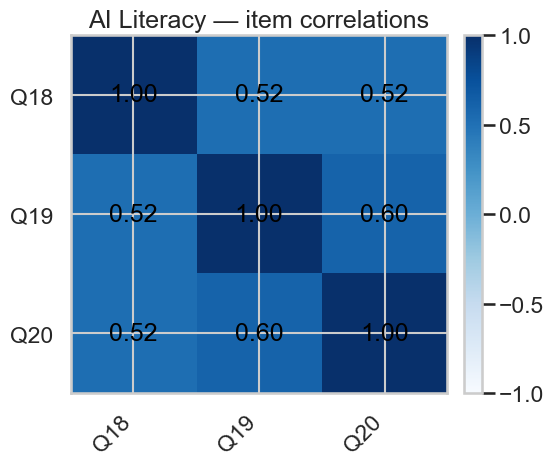

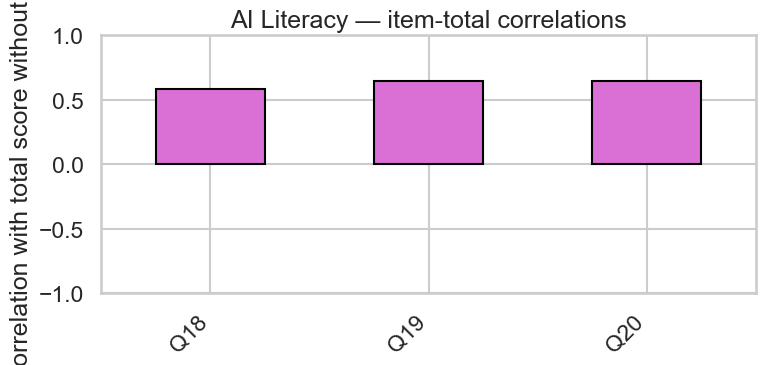

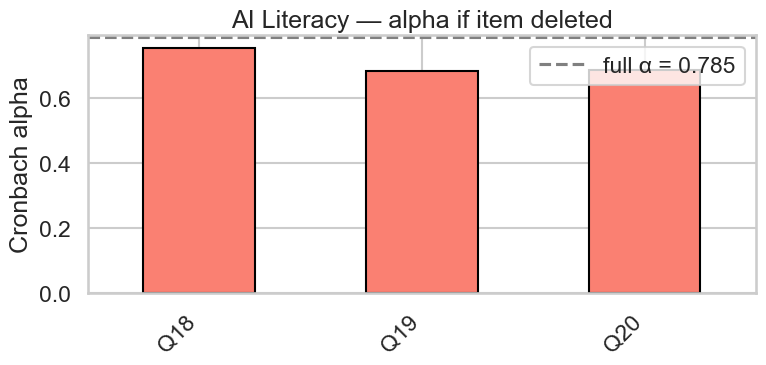

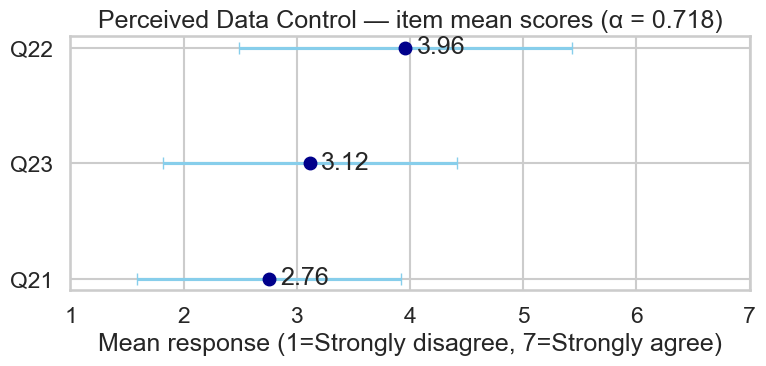

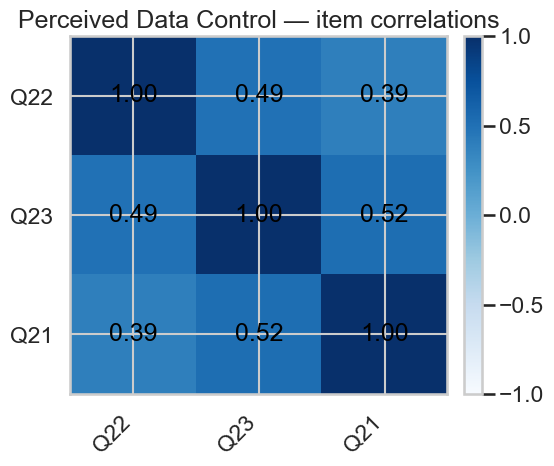

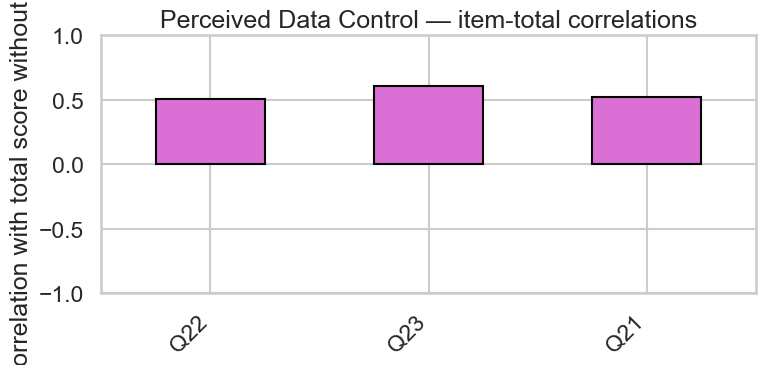

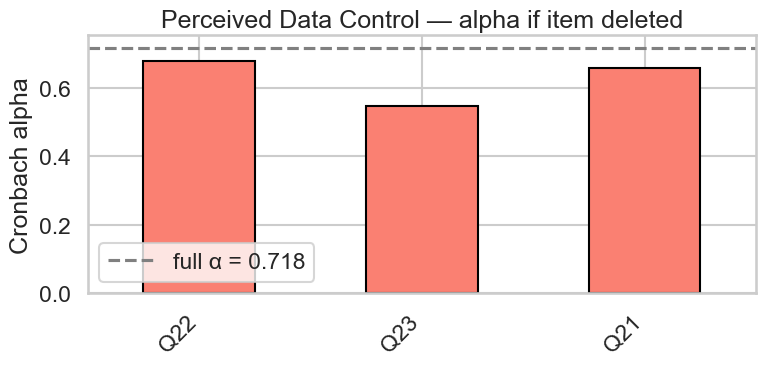

In [26]:
import matplotlib.pyplot as plt

# Build numeric data for the full sample (excluding header rows)
df_all = responses.replace(likert_map).apply(pd.to_numeric, errors='coerce')

for scale, cols in scales.items():
    if len(cols) < 2:
        continue

    scale_data = df_all[cols].dropna()
    if scale_data.empty:
        continue

    item_means = scale_data.mean()
    item_stds = scale_data.std()
    alpha = cronbach_alpha(scale_data)

    # Item mean scores as points with error bars
    fig, ax = plt.subplots(figsize=(8, 4))
    y = range(len(item_means))
    ax.errorbar(item_means, y, xerr=item_stds, fmt='o', color='darkblue', ecolor='skyblue', capsize=4)
    ax.set_title(f'{scale} — item mean scores (α = {alpha:.3f})')
    ax.set_xlabel('Mean response (1=Strongly disagree, 7=Strongly agree)')
    ax.set_xlim(1, 7)
    ax.set_yticks(y)
    ax.set_yticklabels(item_means.index)
    ax.invert_yaxis()
    for i, value in enumerate(item_means):
        ax.text(value + 0.1, i, f'{value:.2f}', va='center')
    plt.tight_layout()
    plt.show()

    # Item correlation heatmap
    corr = scale_data.corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.imshow(corr, cmap='Blues', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'{scale} — item correlations')
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha='right')
    ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f'{corr.iat[i, j]:.2f}', ha='center', va='center', color='black')
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # Item-total correlations
    item_total_corr = []
    total_score = scale_data.sum(axis=1)
    for col in cols:
        item_total = total_score - scale_data[col]
        item_total_corr.append((col, scale_data[col].corr(item_total)))

    item_corr_df = pd.Series({col: corr for col, corr in item_total_corr})
    fig, ax = plt.subplots(figsize=(8, 4))
    item_corr_df.plot(kind='bar', ax=ax, color='orchid', edgecolor='black')
    ax.set_title(f'{scale} — item-total correlations')
    ax.set_ylabel('Correlation with total score without item')
    ax.set_ylim(-1, 1)
    ax.set_xticklabels(item_corr_df.index, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Alpha if item deleted
    alpha_if_deleted = {}
    for col in cols:
        reduced = scale_data.drop(columns=[col])
        alpha_if_deleted[col] = cronbach_alpha(reduced)

    alpha_if_deleted_series = pd.Series(alpha_if_deleted)
    fig, ax = plt.subplots(figsize=(8, 4))
    alpha_if_deleted_series.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.axhline(alpha, color='grey', linestyle='--', label=f'full α = {alpha:.3f}')
    ax.set_title(f'{scale} — alpha if item deleted')
    ax.set_ylabel('Cronbach alpha')
    ax.set_xticklabels(alpha_if_deleted_series.index, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


# Demographic frequencies and percentages for Gender and Age
This section reports the frequency counts and percentage shares for the demographic constructs used in the study.

In [27]:
demographic_columns = {
    'Gender': 'Q27',
    'Age': 'Q26'
}

for label, col in demographic_columns.items():
    if col not in responses.columns:
        print(f"Column {col} for {label} not found in responses.")
        continue

    series = responses[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan})
    total_n = len(series)
    freq = series.value_counts(dropna=False)
    pct = series.value_counts(normalize=True, dropna=False) * 100
    dem_df = pd.DataFrame({'Frequency': freq, 'Percentage': pct}).round({'Percentage': 2})
    print(f"\n{label} distribution (n = {total_n}):")
    display(dem_df)


Gender distribution (n = 241):


,Frequency,Percentage
Q27,,
Female,167,69.29
Male,74,30.71



Age distribution (n = 241):


,Frequency,Percentage
Q26,,
18 - 24,146,60.58
25 - 34,80,33.20
35 - 44,12,4.98
45 - 54,3,1.24


# Manipulation Check
Using Independent T-Test to determine if there is a statistically significant difference between the means of two unrelated, independent groups.

In [28]:
from scipy import stats

# Extract transparency columns
transparency_cols = scales.get('Transparency', [])
print(f"Transparency items: {transparency_cols}\n")

# Get transparency scores for High and Low conditions
high_transparency = df_high[transparency_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
low_transparency = df_low[transparency_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')

# Calculate mean scores (average across items for each participant)
high_transparency_scores = high_transparency.mean(axis=1).dropna()
low_transparency_scores = low_transparency.mean(axis=1).dropna()

# Descriptive statistics
high_mean = high_transparency_scores.mean()
high_std = high_transparency_scores.std()
low_mean = low_transparency_scores.mean()
low_std = low_transparency_scores.std()

print(f"High Disclosure Condition (n={len(high_transparency_scores)}):")
print(f"  Mean: {high_mean:.3f}")
print(f"  Std Dev: {high_std:.3f}")
print(f"\nLow Disclosure Condition (n={len(low_transparency_scores)}):")
print(f"  Mean: {low_mean:.3f}")
print(f"  Std Dev: {low_std:.3f}")

# Independent-samples t-test
t_stat, p_value = stats.ttest_ind(high_transparency_scores, low_transparency_scores)

# Calculate Cohen's d (effect size)
n1, n2 = len(high_transparency_scores), len(low_transparency_scores)
pooled_std = np.sqrt(((n1-1)*high_std**2 + (n2-1)*low_std**2) / (n1 + n2 - 2))
cohens_d = (high_mean - low_mean) / pooled_std

# Interpret effect size
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(f"\n" + "="*60)
print(f"Independent-Samples t-test Results:")
print(f"="*60)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d: {cohens_d:.4f} ({effect_interpretation} effect)")
print(f"Mean difference: {high_mean - low_mean:.3f}")

# Significance interpretation
if p_value < 0.001:
    sig = "p < .001 ***"
elif p_value < 0.01:
    sig = "p < .01 **"
elif p_value < 0.05:
    sig = "p < .05 *"
else:
    sig = "p >= .05 (not significant)"
    
print(f"\nInterpretation: {sig}")
if p_value < 0.05:
    print(f"✓ Participants in the High Disclosure condition perceived significantly")
    print(f"  HIGHER transparency (M={high_mean:.3f}) than those in the Low Disclosure")
    print(f"  condition (M={low_mean:.3f}), t({n1+n2-2})={t_stat:.3f}, p={p_value:.4f}, d={cohens_d:.3f}.")
else:
    print(f"✗ No significant difference in transparency perception between conditions.")


Transparency items: ['Q24', 'Q29', 'Q33']

High Disclosure Condition (n=128):
  Mean: 5.383
  Std Dev: 1.133

Low Disclosure Condition (n=113):
  Mean: 2.634
  Std Dev: 1.241

Independent-Samples t-test Results:
t-statistic: 17.9762
p-value: 0.0000
Cohen's d: 2.3204 (large effect)
Mean difference: 2.749

Interpretation: p < .001 ***
✓ Participants in the High Disclosure condition perceived significantly
  HIGHER transparency (M=5.383) than those in the Low Disclosure
  condition (M=2.634), t(239)=17.976, p=0.0000, d=2.320.


# Reliability and Descriptive Statistics for Key Constructs

This section reports Cronbach's alpha for the five key constructs and their descriptive statistics (mean and standard deviation) by condition.

In [29]:
# Define the five key constructs
key_constructs = [
    'Persuasion Knowledge Activation',
    'Privacy Concern',
    'Customer Loyalty',
    'AI Literacy',
    'Perceived Data Control'
]

# Calculate reliability (Cronbach's alpha) for each construct
print("=" * 90)
print("RELIABILITY ANALYSIS (Cronbach's Alpha)")
print("=" * 90)
reliability_results = {}
for construct in key_constructs:
    if construct in scales:
        cols = scales[construct]
        data = responses.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
        alpha = cronbach_alpha(data)
        reliability_results[construct] = alpha
        print(f"{construct}: α = {alpha:.3f}")
    else:
        print(f"{construct}: NOT FOUND in scales")

print("\n" + "=" * 90)
print("DESCRIPTIVE STATISTICS BY CONDITION")
print("=" * 90)

# Calculate descriptive statistics by condition for each construct
for construct in key_constructs:
    if construct not in scales:
        continue
    
    cols = scales[construct]
    print(f"\n{construct}")
    print("-" * 90)
    
    # Overall sample
    data_all = responses.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_all = data_all.mean(axis=1).dropna()
    print(f"Full Sample (n={len(scores_all)}):")
    print(f"  Mean = {scores_all.mean():.3f}, SD = {scores_all.std():.3f}")
    
    # High condition
    data_high = df_high.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_high = data_high.mean(axis=1).dropna()
    print(f"Enhanced Disclosure (n={len(scores_high)}):")
    print(f"  Mean = {scores_high.mean():.3f}, SD = {scores_high.std():.3f}")
    
    # Low condition
    data_low = df_low.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_low = data_low.mean(axis=1).dropna()
    print(f"Standard Disclosure (n={len(scores_low)}):")
    print(f"  Mean = {scores_low.mean():.3f}, SD = {scores_low.std():.3f}")
    print(f"  Mean Difference (Enhanced - Standard) = {scores_high.mean() - scores_low.mean():.3f}")

# Create a summary table
print("\n" + "=" * 90)
print("SUMMARY TABLE: RELIABILITY AND DESCRIPTIVE STATISTICS")
print("=" * 90)

summary_data = []
for construct in key_constructs:
    if construct not in scales:
        continue
    
    cols = scales[construct]
    
    data_all = responses.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_all = data_all.mean(axis=1).dropna()
    
    data_high = df_high.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_high = data_high.mean(axis=1).dropna()
    
    data_low = df_low.loc[2:, cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    scores_low = data_low.mean(axis=1).dropna()
    
    alpha = reliability_results.get(construct, np.nan)
    
    summary_data.append({
        'Construct': construct,
        'α': alpha,
        'Full M': scores_all.mean(),
        'Full SD': scores_all.std(),
        'Enhanced M': scores_high.mean(),
        'Enhanced SD': scores_high.std(),
        'Standard M': scores_low.mean(),
        'Standard SD': scores_low.std()
    })

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))


RELIABILITY ANALYSIS (Cronbach's Alpha)
Persuasion Knowledge Activation: α = 0.632
Privacy Concern: α = 0.940
Customer Loyalty: α = 0.792
AI Literacy: α = 0.778
Perceived Data Control: α = 0.717

DESCRIPTIVE STATISTICS BY CONDITION

Persuasion Knowledge Activation
------------------------------------------------------------------------------------------
Full Sample (n=239):
  Mean = 5.329, SD = 0.975
Enhanced Disclosure (n=128):
  Mean = 5.383, SD = 0.948
Standard Disclosure (n=113):
  Mean = 5.268, SD = 1.005
  Mean Difference (Enhanced - Standard) = 0.114

Privacy Concern
------------------------------------------------------------------------------------------
Full Sample (n=239):
  Mean = 5.898, SD = 1.239
Enhanced Disclosure (n=128):
  Mean = 6.237, SD = 1.025
Standard Disclosure (n=113):
  Mean = 5.513, SD = 1.339
  Mean Difference (Enhanced - Standard) = 0.724

Customer Loyalty
------------------------------------------------------------------------------------------
Full Sample

# Hypothesis 1 
Participants exposed to high algorithmic disclosure will report lower customer loyalty intention than participants exposed to low algorithmic disclosure.


Customer Loyalty items: ['Q15', 'Q16', 'Q17']
HYPOTHESIS 1: Direct Effect of Disclosure Condition on Loyalty
                            OLS Regression Results                            
Dep. Variable:                Loyalty   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.163
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.143
Time:                        12:59:45   Log-Likelihood:                -363.65
No. Observations:                 241   AIC:                             731.3
Df Residuals:                     239   BIC:                             738.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------

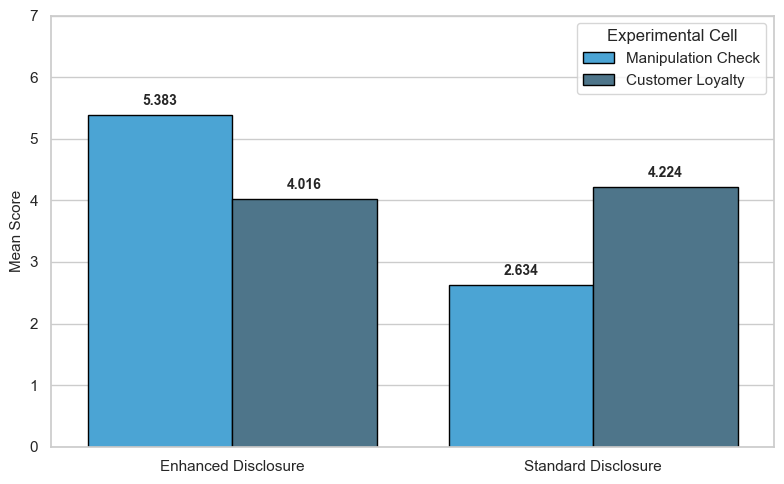


REGRESSION RESULTS:
Intercept (Standard Disclosure mean): 4.224
Slope (Effect of Enhanced Disclosure): -0.209
t-statistic: -1.471
p-value: 0.1427 p ≥ .05 (not significant)
Std. Error: 0.142
R-squared: 0.009
Cohen's d: -0.190 (negligible effect)

INTERPRETATION:
✗ HYPOTHESIS 1 NOT SUPPORTED (no significant effect)
  No significant difference in loyalty intention between conditions,
  b=-0.209, t(239)=-1.471, p=0.1427


In [30]:
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Customer Loyalty items
loyalty_cols = scales.get('Customer Loyalty', [])
print(f"Customer Loyalty items: {loyalty_cols}")

if loyalty_cols:
    # Get loyalty scores for both conditions
    high_loyalty = df_high[loyalty_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
    low_loyalty = df_low[loyalty_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')

    # Calculate mean loyalty scores for each participant
    high_loyalty_scores = high_loyalty.mean(axis=1).dropna()
    low_loyalty_scores = low_loyalty.mean(axis=1).dropna()

    # Compute transparency means for manipulation check
    transparency_cols = scales.get('Transparency', [])
    if transparency_cols:
        high_transparency = df_high[transparency_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
        low_transparency = df_low[transparency_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
        high_transparency_mean = high_transparency.mean(axis=1).dropna().mean()
        low_transparency_mean = low_transparency.mean(axis=1).dropna().mean()
    else:
        high_transparency_mean = np.nan
        low_transparency_mean = np.nan
        print('Warning: Transparency scale not found; manipulation check means unavailable.')

    # Create regression dataset
    df_high_reg = pd.DataFrame({'Condition': 1, 'Loyalty': high_loyalty_scores}).reset_index(drop=True)
    df_low_reg = pd.DataFrame({'Condition': 0, 'Loyalty': low_loyalty_scores}).reset_index(drop=True)
    reg_data = pd.concat([df_high_reg, df_low_reg], ignore_index=True)

    # Prepare variables for regression
    y = reg_data['Loyalty']
    X = reg_data[['Condition']]
    X = sm.add_constant(X)

    # Fit regression model
    model = sm.OLS(y, X).fit()

    # Display results
    print('=' * 70)
    print('HYPOTHESIS 1: Direct Effect of Disclosure Condition on Loyalty')
    print('=' * 70)
    print(model.summary())
    print('\n')

    # Extract key statistics
    intercept = model.params['const']
    slope = model.params['Condition']
    r_squared = model.rsquared
    p_value = model.pvalues['Condition']
    t_stat = model.tvalues['Condition']
    std_err = model.bse['Condition']

    # Descriptive statistics
    high_mean = high_loyalty_scores.mean()
    high_std = high_loyalty_scores.std()
    low_mean = low_loyalty_scores.mean()
    low_std = low_loyalty_scores.std()

    print('\nDESCRIPTIVE STATISTICS:')
    print('=' * 70)
    print(f'Enhanced Disclosure (n={len(high_loyalty_scores)}):')
    print(f'  Mean Loyalty: {high_mean:.3f}')
    print(f'  Std Dev: {high_std:.3f}')
    print(f'  Mean Transparency: {high_transparency_mean:.3f}')
    print(f'\nStandard Disclosure (n={len(low_loyalty_scores)}):')
    print(f'  Mean Loyalty: {low_mean:.3f}')
    print(f'  Std Dev: {low_std:.3f}')
    print(f'  Mean Transparency: {low_transparency_mean:.3f}')
    print(f'  Mean Difference: {high_mean - low_mean:.3f}')

    # Calculate effect size (Cohen\'s d)
    n1, n2 = len(high_loyalty_scores), len(low_loyalty_scores)
    pooled_std = np.sqrt(((n1-1)*high_std**2 + (n2-1)*low_std**2) / (n1 + n2 - 2))
    cohens_d = (high_mean - low_mean) / pooled_std

    if abs(cohens_d) < 0.2:
        effect_interpretation = 'negligible'
    elif abs(cohens_d) < 0.5:
        effect_interpretation = 'small'
    elif abs(cohens_d) < 0.8:
        effect_interpretation = 'medium'
    else:
        effect_interpretation = 'large'
    
    # Plot exact thesis means for the manipulation check and direct effect comparison
    sns.set_theme(style='whitegrid')
    data = {
        'Condition': ['Manipulation Check', 'Customer Loyalty'],
        'Enhanced Disclosure': [5.383, 4.016],  # Manipulation Check Means
        'Standard Disclosure': [2.634, 4.224]         # H1 Direct Effect Means
    }
    df_plot = pd.DataFrame(data)
    df_melted = pd.melt(df_plot, id_vars=['Condition'], var_name='Metric', value_name='Mean Score')

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#34abeb', '#447894']
    ax = sns.barplot(
        x='Metric',
        y='Mean Score',
        hue='Condition',
        data=df_melted,
        palette=colors,
        edgecolor='black',
        linewidth=1,
        ax=ax
    )
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold')

    ax.set_ylabel('Mean Score', fontsize=11)
    ax.set_xlabel('', fontsize=11)
    ax.set_ylim(0, 7)
    ax.legend(title='Experimental Cell', loc='upper right')

    plt.tight_layout()
    plt.show()

    # Significance interpretation
    if p_value < 0.001:
        sig = 'p < .001 ***'
    elif p_value < 0.01:
        sig = 'p < .01 **'
    elif p_value < 0.05:
        sig = 'p < .05 *'
    else:
        sig = 'p ≥ .05 (not significant)'

    print('\nREGRESSION RESULTS:')
    print('=' * 70)
    print(f'Intercept (Standard Disclosure mean): {intercept:.3f}')
    print(f'Slope (Effect of Enhanced Disclosure): {slope:.3f}')
    print(f't-statistic: {t_stat:.3f}')
    print(f'p-value: {p_value:.4f} {sig}')
    print(f'Std. Error: {std_err:.3f}')
    print(f'R-squared: {r_squared:.3f}')
    print(f'Cohen\'s d: {cohens_d:.3f} ({effect_interpretation} effect)')

    print('\nINTERPRETATION:')
    print('=' * 70)
    if p_value < 0.05:
        if slope < 0:
            print('✓ HYPOTHESIS 1 SUPPORTED (direct effect)')
            print('  Participants in the Enhanced Disclosure condition reported')
            print(f'  SIGNIFICANTLY LOWER loyalty intention (M={high_mean:.3f}, SD={high_std:.3f})')
            print(f'  compared to the Standard Disclosure condition (M={low_mean:.3f}, SD={low_std:.3f}),')
            print(f'  b={slope:.3f}, t({len(reg_data)-2})={t_stat:.3f}, p={p_value:.4f}, d={cohens_d:.3f}')
        else:
            print('✗ HYPOTHESIS 1 NOT SUPPORTED (opposite direction)')
            print('  Enhanced Disclosure condition predicts HIGHER loyalty intention.')
    else:
        print('✗ HYPOTHESIS 1 NOT SUPPORTED (no significant effect)')
        print('  No significant difference in loyalty intention between conditions,')
        print(f'  b={slope:.3f}, t({len(reg_data)-2})={t_stat:.3f}, p={p_value:.4f}')
else:
    print('⚠ Could not find \'Customer Loyalty\' scale in the data.')

# Mediation Analysis (PROCESS Model 4)

Test whether transparency disclosure affects customer loyalty indirectly through Persuasion Knowledge Activation (PKA) and Privacy Concern.

In [31]:
import statsmodels.api as sm
from scipy import stats

def run_process_model4_single_mediator(mediator_scale, outcome_scale='Customer Loyalty'):
    if mediator_scale not in scales:
        print(f"Scale '{mediator_scale}' not found.")
        return
    if outcome_scale not in scales:
        print(f"Scale '{outcome_scale}' not found.")
        return

    mediator_scores = responses[scales[mediator_scale]].replace(likert_map).apply(pd.to_numeric, errors='coerce').mean(axis=1)
    outcome_scores = responses[scales[outcome_scale]].replace(likert_map).apply(pd.to_numeric, errors='coerce').mean(axis=1)
    condition = responses['Condition'].map({'High': 1, 'Low': 0})

    med_data = pd.DataFrame({
        'Condition': condition,
        'Mediator': mediator_scores,
        'Loyalty': outcome_scores
    }).dropna()

    if med_data.empty:
        print(f"No complete cases for mediation using {mediator_scale}.")
        return

    model_a = sm.OLS(med_data['Mediator'], sm.add_constant(med_data[['Condition']])).fit()
    model_b = sm.OLS(med_data['Loyalty'], sm.add_constant(med_data[['Condition', 'Mediator']])).fit()
    model_total = sm.OLS(med_data['Loyalty'], sm.add_constant(med_data[['Condition']])).fit()

    a = model_a.params['Condition']
    b = model_b.params['Mediator']
    cp = model_b.params['Condition']
    ct = model_total.params['Condition']

    se_a = model_a.bse['Condition']
    se_b = model_b.bse['Mediator']
    indirect = a * b
    se_indirect = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
    z = indirect / se_indirect if se_indirect > 0 else np.nan
    p_sobel = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    boot_iterations = 5000
    boot_estimates = []
    rng = np.random.RandomState(123)
    for _ in range(boot_iterations):
        sample = med_data.sample(n=len(med_data), replace=True, random_state=rng.randint(0, 2**31 - 1))
        a_b = sm.OLS(sample['Mediator'], sm.add_constant(sample[['Condition']])).fit().params['Condition']
        b_b = sm.OLS(sample['Loyalty'], sm.add_constant(sample[['Condition', 'Mediator']])).fit().params['Mediator']
        boot_estimates.append(a_b * b_b)

    boot_estimates = np.array(boot_estimates)
    ci_lower = np.percentile(boot_estimates, 2.5)
    ci_upper = np.percentile(boot_estimates, 97.5)

    print('\n' + '=' * 90)
    print(f'Mediation test for {mediator_scale} (PROCESS Model 4)')
    print('=' * 90)
    print(f"  a path (Condition -> {mediator_scale}): b={a:.3f}, SE={se_a:.3f}, p={model_a.pvalues['Condition']:.4f}")
    print(f"  b path ({mediator_scale} -> Loyalty controlling for Condition): b={b:.3f}, SE={se_b:.3f}, p={model_b.pvalues['Mediator']:.4f}")
    print(f"  direct effect c' (Condition -> Loyalty controlling for mediator): b={cp:.3f}, SE={model_b.bse['Condition']:.3f}, p={model_b.pvalues['Condition']:.4f}")
    print(f"  total effect c (Condition -> Loyalty): b={ct:.3f}, SE={model_total.bse['Condition']:.3f}, p={model_total.pvalues['Condition']:.4f}")
    print(f'  indirect effect ab: {indirect:.3f}, SE={se_indirect:.3f}, z={z:.3f}, p={p_sobel:.4f}')
    print(f'  bootstrapped 95% CI for indirect effect: [{ci_lower:.3f}, {ci_upper:.3f}]')
    if ci_lower > 0 or ci_upper < 0:
        print('  -> Indirect effect is significant at the 95% bootstrap level.')
    else:
        print('  -> Indirect effect is not significant at the 95% bootstrap level.')
    print('')

run_process_model4_single_mediator('Persuasion Knowledge Activation')
run_process_model4_single_mediator('Privacy Concern')


Mediation test for Persuasion Knowledge Activation (PROCESS Model 4)
  a path (Condition -> Persuasion Knowledge Activation): b=0.114, SE=0.126, p=0.3645
  b path (Persuasion Knowledge Activation -> Loyalty controlling for Condition): b=0.044, SE=0.073, p=0.5476
  direct effect c' (Condition -> Loyalty controlling for mediator): b=-0.214, SE=0.142, p=0.1346
  total effect c (Condition -> Loyalty): b=-0.209, SE=0.142, p=0.1427
  indirect effect ab: 0.005, SE=0.010, z=0.502, p=0.6157
  bootstrapped 95% CI for indirect effect: [-0.026, 0.034]
  -> Indirect effect is not significant at the 95% bootstrap level.


Mediation test for Privacy Concern (PROCESS Model 4)
  a path (Condition -> Privacy Concern): b=0.724, SE=0.153, p=0.0000
  b path (Privacy Concern -> Loyalty controlling for Condition): b=-0.248, SE=0.058, p=0.0000
  direct effect c' (Condition -> Loyalty controlling for mediator): b=-0.029, SE=0.143, p=0.8383
  total effect c (Condition -> Loyalty): b=-0.209, SE=0.142, p=0.1427


# Moderation Analysis (Process Model 1)
To test hypotheses H8 and H9: whether AI Literacy and Perceived Data Control moderate the effect of algorithmic disclosure conditions on downstream outcomes (PKA, Privacy Concern, and Customer Loyalty)

In [32]:
import numpy as np

def run_process_model1_moderation(moderator_scale, outcome_scale, hypothesis_label):
    """Run moderation analysis (PROCESS Model 1) for a given moderator and outcome."""
    if moderator_scale not in scales:
        print(f"Scale '{moderator_scale}' not found.")
        return
    if outcome_scale not in scales:
        print(f"Scale '{outcome_scale}' not found.")
        return

    moderator_scores = responses[scales[moderator_scale]].replace(likert_map).apply(pd.to_numeric, errors='coerce').mean(axis=1)
    outcome_scores = responses[scales[outcome_scale]].replace(likert_map).apply(pd.to_numeric, errors='coerce').mean(axis=1)
    condition = responses['Condition'].map({'High': 1, 'Low': 0})

    mod_data = pd.DataFrame({
        'Condition': condition,
        'Moderator': moderator_scores,
        'Outcome': outcome_scores
    }).dropna()

    if mod_data.empty:
        print(f"No complete cases for moderation using {moderator_scale}.")
        return

    # Center the moderator
    mod_data['Moderator_c'] = mod_data['Moderator'] - mod_data['Moderator'].mean()
    mod_data['Interaction'] = mod_data['Condition'] * mod_data['Moderator_c']

    # Fit the model
    model = sm.OLS(mod_data['Outcome'], sm.add_constant(mod_data[['Condition', 'Moderator_c', 'Interaction']])).fit()

    # Calculate conditional effects at low and high moderator values (±1 SD)
    moderator_mean = mod_data['Moderator'].mean()
    moderator_sd = mod_data['Moderator'].std()
    low_mod_value = moderator_mean - moderator_sd
    high_mod_value = moderator_mean + moderator_sd
    
    conditional_low = model.params['Condition'] + model.params['Interaction'] * (low_mod_value - moderator_mean)
    conditional_high = model.params['Condition'] + model.params['Interaction'] * (high_mod_value - moderator_mean)

    # Median split for simple slopes
    median_value = mod_data['Moderator'].median()
    mod_data['Group'] = np.where(mod_data['Moderator'] > median_value, 'High', 'Low')
    
    print('\n' + '=' * 100)
    print(f'{hypothesis_label}')
    print(f'Moderator: {moderator_scale} | Outcome: {outcome_scale}')
    print('=' * 100)
    print(model.summary())
    
    # Extract and display key results
    b_condition = model.params['Condition']
    b_moderator = model.params['Moderator_c']
    b_interaction = model.params['Interaction']
    p_interaction = model.pvalues['Interaction']
    
    print(f'\nKey Effects:')
    print(f'  Main effect of Condition (b): {b_condition:.4f}, SE: {model.bse["Condition"]:.4f}, p: {model.pvalues["Condition"]:.4f}')
    print(f'  Main effect of {moderator_scale} (b): {b_moderator:.4f}, SE: {model.bse["Moderator_c"]:.4f}, p: {model.pvalues["Moderator_c"]:.4f}')
    print(f'  Interaction effect (b): {b_interaction:.4f}, SE: {model.bse["Interaction"]:.4f}, p: {p_interaction:.4f}')
    
    print(f'\nConditional Effects of Condition on {outcome_scale}:')
    print(f'  At low {moderator_scale} ({low_mod_value:.3f}, -1 SD): b = {conditional_low:.4f}')
    print(f'  At high {moderator_scale} ({high_mod_value:.3f}, +1 SD): b = {conditional_high:.4f}')
    
    print(f'\nSimple Slopes by Median-Split Group:')
    for grp in ['Low', 'High']:
        grp_data = mod_data[mod_data['Group'] == grp]
        if grp_data.shape[0] < 2:
            print(f'  {grp}: insufficient data')
            continue
        grp_model = sm.OLS(grp_data['Outcome'], sm.add_constant(grp_data[['Condition']])).fit()
        b_slope = grp_model.params['Condition']
        p_slope = grp_model.pvalues['Condition']
        significance = '***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns'
        print(f'  {grp} {moderator_scale} (n={len(grp_data)}): b = {b_slope:.4f}, SE = {grp_model.bse["Condition"]:.4f}, p = {p_slope:.4f} {significance}')
    
    # Interpretation
    print(f'\nInterpretation:')
    if p_interaction < 0.05:
        print(f'  ✓ Significant moderation effect (p = {p_interaction:.4f})')
        if b_interaction > 0:
            print(f'  The effect of disclosure condition on {outcome_scale} becomes STRONGER as {moderator_scale} increases.')
        else:
            print(f'  The effect of disclosure condition on {outcome_scale} becomes WEAKER as {moderator_scale} increases.')
    else:
        print(f'  ✗ No significant moderation effect (p = {p_interaction:.4f})')

# Define the four moderation tests
moderation_tests = [
    ('AI Literacy', 'Persuasion Knowledge Activation', 'H8a: AI Literacy moderates effect on PKA'),
    ('AI Literacy', 'Customer Loyalty', 'H8b: AI Literacy moderates effect on Customer Loyalty'),
    ('Perceived Data Control', 'Privacy Concern', 'H9a: Perceived Data Control moderates effect on Privacy Concern'),
    ('Perceived Data Control', 'Customer Loyalty', 'H9b: Perceived Data Control moderates effect on Customer Loyalty')
]

print('\n' + '=' * 100)
print('MODERATION ANALYSIS: Tests of H8 and H9')
print('=' * 100)

for moderator, outcome, hypothesis in moderation_tests:
    run_process_model1_moderation(moderator, outcome, hypothesis)


MODERATION ANALYSIS: Tests of H8 and H9

H8a: AI Literacy moderates effect on PKA
Moderator: AI Literacy | Outcome: Persuasion Knowledge Activation
                            OLS Regression Results                            
Dep. Variable:                Outcome   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.212
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0874
Time:                        12:59:57   Log-Likelihood:                -332.01
No. Observations:                 241   AIC:                             672.0
Df Residuals:                     237   BIC:                             686.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      

# Simple Sloped Plot
### Interaction of Disclosure Condition and AI Literacy on PKA (figure 6)

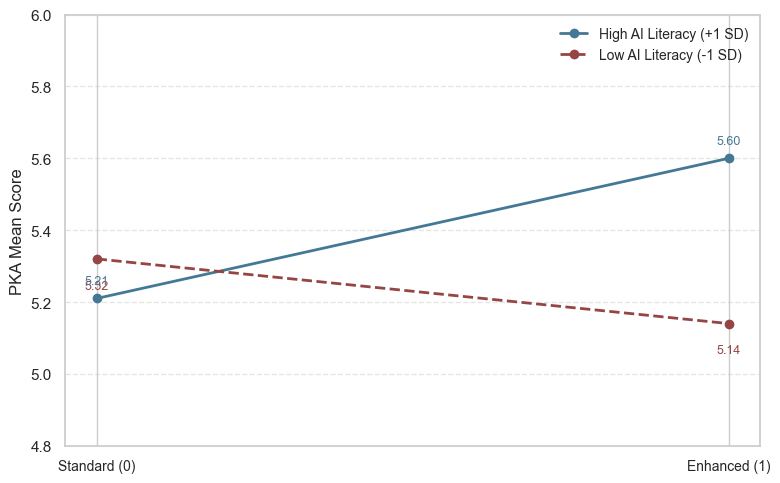

In [48]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['Standard (0)', 'Enhanced (1)']
condition_codes = [0, 1]

pka_low = [5.32, 5.14]
pka_high = [5.21, 5.60]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(condition_codes, pka_high, marker='o', color='#447894', linestyle='-', linewidth=2, label='High AI Literacy (+1 SD)')
ax.plot(condition_codes, pka_low, marker='o', color='#964545', linestyle='--', linewidth=2, label='Low AI Literacy (-1 SD)')

ax.set_xticks(condition_codes)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylabel('PKA Mean Score', fontsize=12)
ax.set_ylim(4.8, 6.0)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for x_val, y_val in zip(condition_codes, pka_low):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, -15), textcoords='offset points',
                ha='center', va='top', color='#964545', fontsize=9)
for x_val, y_val in zip(condition_codes, pka_high):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', color='#447894', fontsize=9)

fig.tight_layout()
plt.show()

### Interaction of Disclosure Condition and AI Literacy on customer Loyalty (figure 7)

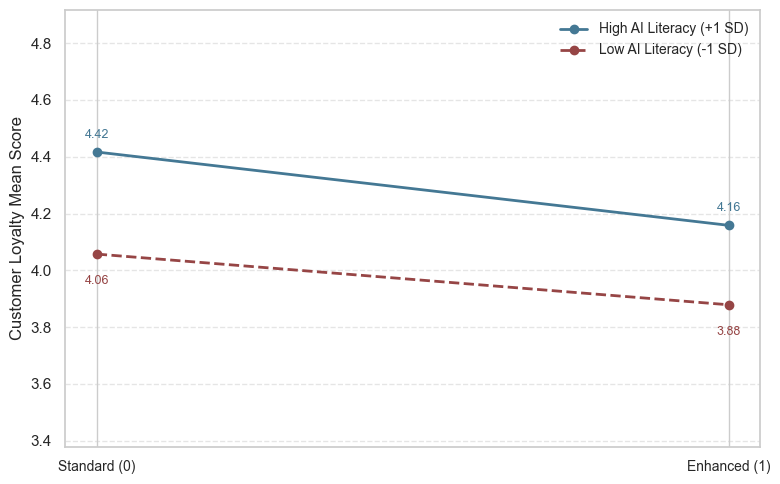

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

conditions = ['Standard (0)', 'Enhanced (1)']
condition_codes = [0, 1]

loyalty_cols = scales.get('Customer Loyalty', [])
ai_cols = scales.get('AI Literacy', [])

if not loyalty_cols or not ai_cols:
    raise ValueError('Customer Loyalty or AI Literacy scale not found in the notebook data.')

analysis_df = responses.loc[2:, loyalty_cols + ai_cols + ['Condition']].copy()
analysis_df[loyalty_cols + ai_cols] = analysis_df[loyalty_cols + ai_cols].replace(likert_map).apply(pd.to_numeric, errors='coerce')
analysis_df = analysis_df.dropna(subset=loyalty_cols + ai_cols + ['Condition'])
analysis_df['Loyalty'] = analysis_df[loyalty_cols].mean(axis=1)
analysis_df['AI_Literacy'] = analysis_df[ai_cols].mean(axis=1)
median_ai = analysis_df['AI_Literacy'].median()
analysis_df['AI_group'] = np.where(analysis_df['AI_Literacy'] > median_ai, 'High', 'Low')

loyalty_means = analysis_df.groupby(['AI_group', 'Condition'])['Loyalty'].mean().unstack()

loyalty_low = [
    loyalty_means.at['Low', 'Low'],
    loyalty_means.at['Low', 'High']
]
loyalty_high = [
    loyalty_means.at['High', 'Low'],
    loyalty_means.at['High', 'High']
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(condition_codes, loyalty_high, marker='o', color='#447894', linestyle='-', linewidth=2, label='High AI Literacy (+1 SD)')
ax.plot(condition_codes, loyalty_low, marker='o', color='#964545', linestyle='--', linewidth=2, label='Low AI Literacy (-1 SD)')

ax.set_xticks(condition_codes)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylabel('Customer Loyalty Mean Score', fontsize=12)
ax.set_ylim(min(min(loyalty_low), min(loyalty_high)) - 0.5, max(max(loyalty_low), max(loyalty_high)) + 0.5)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for x_val, y_val in zip(condition_codes, loyalty_low):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, -15), textcoords='offset points',
                ha='center', va='top', color='#964545', fontsize=9)
for x_val, y_val in zip(condition_codes, loyalty_high):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', color='#447894', fontsize=9)

fig.tight_layout()
plt.show()

### Interaction of Disclosure Condition and Perceived Data Control on Privacy Concern (figure 8)

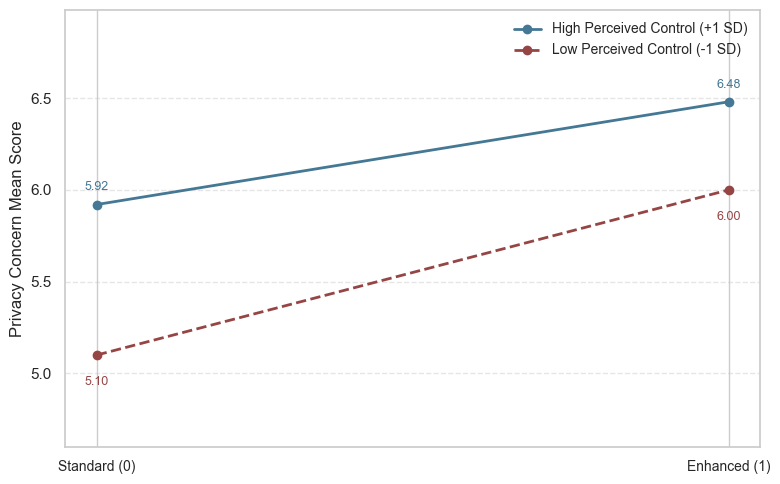

In [50]:
import matplotlib.pyplot as plt

conditions = ['Standard (0)', 'Enhanced (1)']
condition_codes = [0, 1]

# Replace these with your actual means:
privacy_low = [5.10, 6.00]   # [Standard LowControl, Enhanced LowControl]
privacy_high = [5.92, 6.48]  # [Standard HighControl, Enhanced HighControl]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(condition_codes, privacy_high, marker='o', color='#447894', linestyle='-', linewidth=2, label='High Perceived Control (+1 SD)')
ax.plot(condition_codes, privacy_low,  marker='o', color='#964545', linestyle='--', linewidth=2, label='Low Perceived Control (-1 SD)')

ax.set_xticks(condition_codes)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_ylabel('Privacy Concern Mean Score', fontsize=12)
ax.set_ylim(min(min(privacy_low), min(privacy_high)) - 0.5, max(max(privacy_low), max(privacy_high)) + 0.5)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for x_val, y_val in zip(condition_codes, privacy_low):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, -15), textcoords='offset points',
                ha='center', va='top', color='#964545', fontsize=9)
for x_val, y_val in zip(condition_codes, privacy_high):
    ax.annotate(f'{y_val:.2f}', xy=(x_val, y_val), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', color='#447894', fontsize=9)

fig.tight_layout()
plt.show()

### figure 9 here

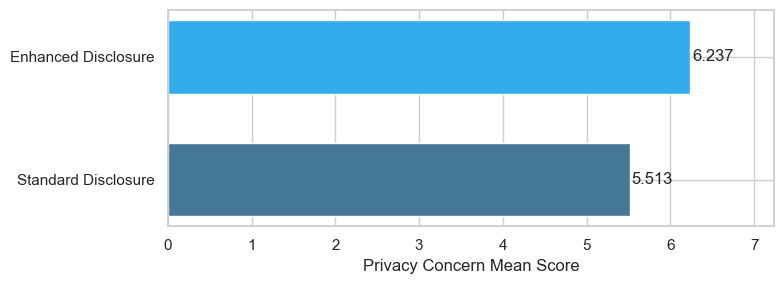

In [51]:
import matplotlib.pyplot as plt

conditions = ['Enhanced Disclosure', 'Standard Disclosure']
scores = [6.237, 5.513]
colors = ['#34abeb', '#447894']

fig, ax = plt.subplots(figsize=(8, 3))
y_positions = range(len(conditions))
ax.barh(y_positions, scores, color=colors, height=0.6)
ax.set_yticks(y_positions)
ax.set_yticklabels(conditions)
ax.invert_yaxis()
ax.set_xlim(0, max(scores) + 1)
ax.set_xlabel('Privacy Concern Mean Score')
for i, v in enumerate(scores):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

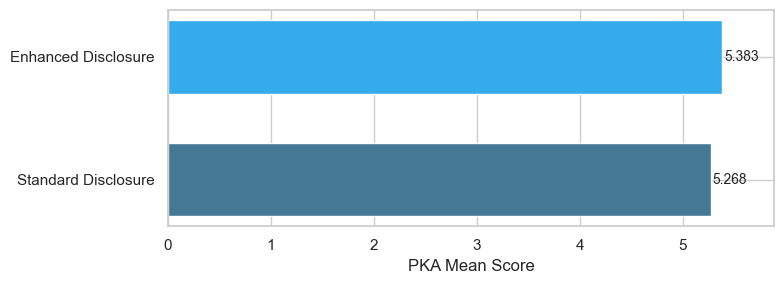

In [52]:
import matplotlib.pyplot as plt

conditions = ['Enhanced Disclosure', 'Standard Disclosure']
scores = [5.383, 5.268]
colors = ['#34abeb', '#447894']

fig, ax = plt.subplots(figsize=(8, 3))
y_positions = range(len(conditions))
ax.barh(y_positions, scores, color=colors, height=0.6)
ax.set_yticks(y_positions)
ax.set_yticklabels(conditions, fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, max(scores) + 0.5)
ax.set_xlabel('PKA Mean Score', fontsize=12)
for i, v in enumerate(scores):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()